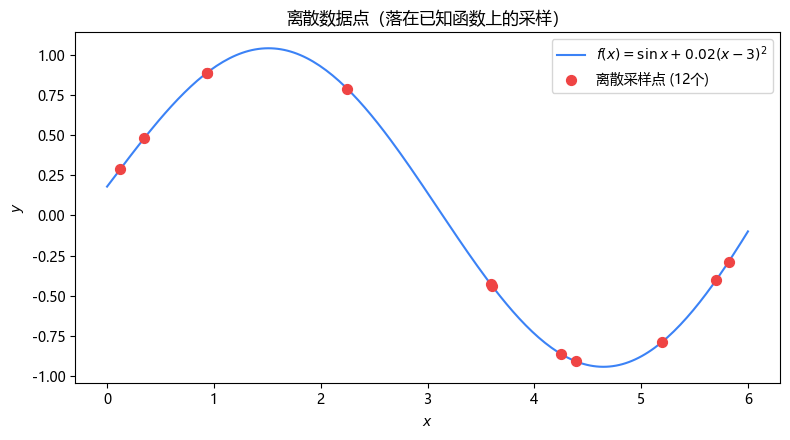

生成了 12 个离散点，x 范围 [0.124, 5.819]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 中文显示：Windows 下用微软雅黑，没有则回退
mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False

# 随意挑个非线性函数：sin 叠加一个二次项，有点起伏好看出插值效果
def f(x):
    return np.sin(x) + 0.02 * (x - 3)**2

# 在 [0, 6] 上随机取 12 个离散点，落在 f(x) 上（不加噪声，纯函数值）
np.random.seed(42)
x_data = np.sort(np.random.uniform(0, 6, 12))
y_data = f(x_data)

# 画连续函数曲线 + 离散点
x_dense = np.linspace(0, 6, 200)
y_dense = f(x_dense)

plt.figure(figsize=(8, 4.5))
plt.plot(x_dense, y_dense, color='#3b82f6', linewidth=1.5,
         label=r'$f(x)=\sin x + 0.02(x-3)^2$')
plt.scatter(x_data, y_data, color='#ef4444', s=50, zorder=5, label='离散采样点 (12个)')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('离散数据点（落在已知函数上的采样）')
plt.legend()
plt.tight_layout()
plt.show()

print(f"生成了 {len(x_data)} 个离散点，x 范围 [{x_data[0]:.3f}, {x_data[-1]:.3f}]")

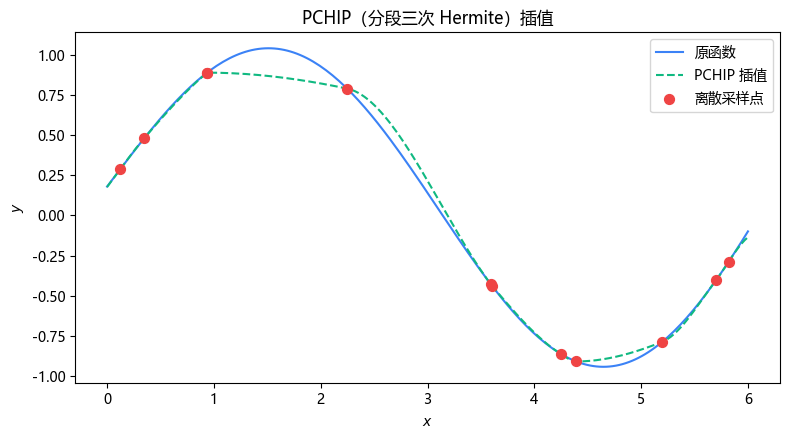

PCHIP MSE: 4.81e-03


In [3]:
from scipy.interpolate import PchipInterpolator

# PCHIP：分段三次 Hermite 插值，保持单调性，不会像样条那样过冲振荡
p = PchipInterpolator(x_data, y_data)

x_dense = np.linspace(0, 6, 200)
y_pchip = p(x_dense)

plt.figure(figsize=(8, 4.5))
plt.plot(x_dense, y_dense, color='#3b82f6', linewidth=1.5, label='原函数')
plt.plot(x_dense, y_pchip, '--', color='#10b981', linewidth=1.5, label='PCHIP 插值')
plt.scatter(x_data, y_data, color='#ef4444', s=50, zorder=5, label='离散采样点')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('PCHIP（分段三次 Hermite）插值')
plt.legend()
plt.tight_layout()
plt.show()

print(f"PCHIP MSE: {np.mean((y_pchip - y_dense)**2):.2e}")

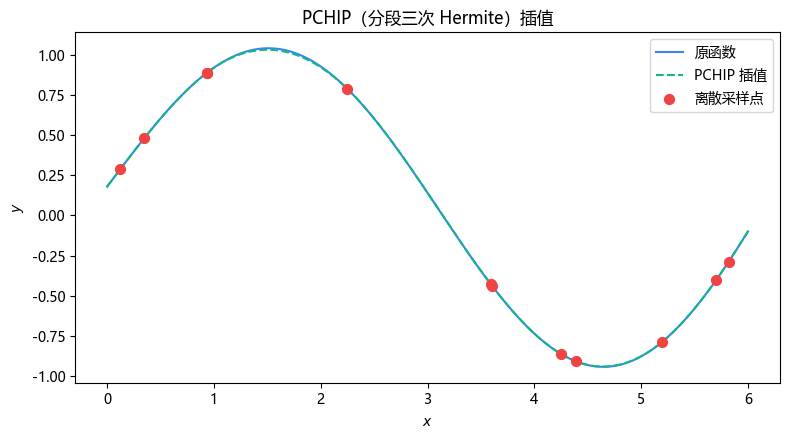

PCHIP MSE: 9.46e-06


In [4]:
from scipy.interpolate import CubicSpline

# PCHIP：分段三次 Hermite 插值，保持单调性，不会像样条那样过冲振荡
p = CubicSpline(x_data, y_data)

x_dense = np.linspace(0, 6, 200)
y_pchip = p(x_dense)

plt.figure(figsize=(8, 4.5))
plt.plot(x_dense, y_dense, color='#3b82f6', linewidth=1.5, label='原函数')
plt.plot(x_dense, y_pchip, '--', color='#10b981', linewidth=1.5, label='PCHIP 插值')
plt.scatter(x_data, y_data, color='#ef4444', s=50, zorder=5, label='离散采样点')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('PCHIP（分段三次 Hermite）插值')
plt.legend()
plt.tight_layout()
plt.show()

print(f"PCHIP MSE: {np.mean((y_pchip - y_dense)**2):.2e}")